In [462]:
import numpy as np
import pickle
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.csgraph import laplacian
from sklearn.metrics import mean_squared_error, confusion_matrix, r2_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from math import sqrt
# import pycircos
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap
import itertools

import torch
import torch.nn as nn
import torch_geometric as tg
import torch.nn.init as init
import torch.nn.functional as F
from torch_geometric.utils import softmax
import torch.nn.utils as utils
from torch.autograd import Variable
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax

from GraphNetConv import GraphNetConv

In [582]:
def obs_domain(scaled_limits, scaled_vector):
    min_limit, max_limit = scaled_limits[0], scaled_limits[1]
    unscaled_vector = scaled_vector*(max_limit-min_limit) + min_limit
#     mean_limit, std_limit = scaled_limits[0], scaled_limits[1]
#     unscaled_vector = scaled_vector * std_limit + mean_limit
    return unscaled_vector

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def psnr(true, pred):
    mse = mean_squared_error(true, pred)
    max_pixel_value = np.max(true)
    if mse == 0:
        return float('inf')  # If MSE is zero, PSNR is infinite
    return 20 * np.log10(max_pixel_value / np.sqrt(mse))

In [583]:
habs_paired_data = pd.read_pickle('../data/66 ROIs processing HABS_ADNI/habs_paired_data.pkl')
adni_paired_data = pd.read_pickle('../data/66 ROIs processing HABS_ADNI/adni_paired_data.pkl')
combined_paired_data = pd.concat([habs_paired_data, adni_paired_data])

cohort = 'adni'
split = 'test'

In [757]:
fkpp_epoch_map = {
    (0.00645, 0.738): [1500, 1500],
    (0.0645, 0.738): [2499, 2499],
    (0.645, 0.738): [1500, 1500],
    
    (0.00645, 0.0738): [1500, 1000],
    (0.0645, 0.0738): [2499, 500],
    (0.645, 0.0738): [1500, 2000],
    
    (0.00645, 0.00738): [1000, 1000],
    (0.0645, 0.00738): [1000, 2000],
    (0.645, 0.00738): [1000, 750],
}

In [634]:
esm_epoch_map = {
    (8.804e-6, 0.01): [2499, 750],
    (8.804e-5, 0.01): [1500, 2499],
    (8.804e-4, 0.01): [1000, 2000],
    
    (8.804e-6, 0.001): [1500, 2000],
    (8.804e-5, 0.001): [750, 1500],
    (8.804e-4, 0.001): [2499, 2499],
    
    (8.804e-6, 0.0001): [2000, 2499],
    (8.804e-5, 0.0001): [1000, 2499],
    (8.804e-4, 0.0001): [2499, 750],
}

In [745]:
fkpp_p1 = [0.00645, 0.0645, 0.645]
fkpp_p2 = [0.00738, 0.0738, 0.738]

esm_p1 = [8.804e-6, 8.804e-5, 8.804e-4]
esm_p2 = [0.0001, 0.001, 0.01]

spaces = ['obs', 'lat']

rows = []
encoder = GraphNet_ED()
model = GraphNet()
decoder = GraphNet_ED()

p1_vals = fkpp_p1
p2_vals = fkpp_p2
epoch_map = fkpp_epoch_map
reg = 'fkpp'
def fmt_sci(x):
    return f"{x:.3e}".replace("e-0", "e-")

for p1, p2 in itertools.product(p1_vals, p2_vals):
    obs_epoch, lat_epoch = epoch_map.get((p1, p2))
    for space in spaces:
        resultname = f'{reg}_{space}_{p1}_{p2}'
        print(resultname)
        if space == 'obs':
            epoch = obs_epoch
        else:
            epoch = lat_epoch
        
        best_encoder_state = torch.load(f'../results revision/{cohort}/{resultname}_best_encoder_state_{epoch}.pth')
        best_model_state = torch.load(f'../results revision/{cohort}/{resultname}_best_model_state_{epoch}.pth')
        best_decoder_state = torch.load(f'../results revision/{cohort}/{resultname}_best_decoder_state_{epoch}.pth')

        encoder.load_state_dict(best_encoder_state)
        model.load_state_dict(best_model_state)
        decoder.load_state_dict(best_decoder_state)
        model.eval()
        encoder.eval()
        decoder.eval()

        outputs = []
        for data in DataLoader(test_data, batch_size = 8, 
                                 shuffle = False, drop_last = False):
            z_x = encoder(data.x, data.edge_index, data.edge_weight+1e-6)
            z_yhat = model(z_x, data.edge_index, data.edge_weight+1e-6)
            yhat = decoder(z_yhat, data.edge_index, data.edge_weight+1e-6)
            outputs.append(yhat.detach())
        outputs = torch.split(torch.cat(outputs), 66)
        
        row = {
            "reg": reg,
            "space": space,
            "param1": float(p1),
            "param2": float(p2),
            "epoch": int(epoch),
            "resultname": resultname,
            "outputs": outputs
            }
        rows.append(row)

fkpp_obs_0.00645_0.00738
fkpp_lat_0.00645_0.00738
fkpp_obs_0.00645_0.0738
fkpp_lat_0.00645_0.0738
fkpp_obs_0.00645_0.738
fkpp_lat_0.00645_0.738
fkpp_obs_0.0645_0.00738
fkpp_lat_0.0645_0.00738
fkpp_obs_0.0645_0.0738
fkpp_lat_0.0645_0.0738
fkpp_obs_0.0645_0.738
fkpp_lat_0.0645_0.738
fkpp_obs_0.645_0.00738
fkpp_lat_0.645_0.00738
fkpp_obs_0.645_0.0738
fkpp_lat_0.645_0.0738
fkpp_obs_0.645_0.738
fkpp_lat_0.645_0.738


In [821]:
### plots compare with no_reg - COMMENT OUT IF DOING PARAMETER SEARCH
rows = []
resultname_settings_for_explainer = ["no_reg", "fkpp_lat_0.0645_0.0738", "esm_lat_8.804e-5_0.001" ]
epochs_settings_for_explainer = ['', '_500', '_1500']

for idx in range(len(resultname_settings_for_explainer)):
    resultname = resultname_settings_for_explainer[idx]
    epoch = epochs_settings_for_explainer[idx]
    
    encoder.load_state_dict(torch.load(f'../results revision/{cohort}/{resultname}_best_encoder_state{epoch}.pth')) 
    model.load_state_dict(torch.load(f'../results revision/{cohort}/{resultname}_best_model_state{epoch}.pth'))
    decoder.load_state_dict(torch.load(f'../results revision/{cohort}/{resultname}_best_decoder_state{epoch}.pth')) 
    
    model.eval()
    encoder.eval()
    decoder.eval()

    outputs = []
    for data in DataLoader(test_data, batch_size = 8, 
                             shuffle = False, drop_last = False):
        z_x = encoder(data.x, data.edge_index, data.edge_weight+1e-6)
        z_yhat = model(z_x, data.edge_index, data.edge_weight+1e-6)
        yhat = decoder(z_yhat, data.edge_index, data.edge_weight+1e-6)
        outputs.append(yhat.detach())
    outputs = torch.split(torch.cat(outputs), 66)

    row = {
        "resultname": resultname,
        "outputs": outputs
        }
    rows.append(row)

In [822]:
reg_resultnames = [row['resultname'] for row in rows]

In [823]:
### convert to obs space
data_objects = test_data
paired_data = adni_paired_data.copy()
regularizers_comparison = []

for index in range(len(data_objects)):
    subid = data_objects[index].subid
    cohort = data_objects[index].cohort
    tp1, tp2 = data_objects[index].tps
    row_idx = paired_data.index[(paired_data['Subject ID'] == subid) & 
                            (paired_data['tp1'] == tp1) & (paired_data['tp2'] == tp2)]
    row = paired_data.loc[row_idx]
    limits = row['Scale Limits'].values[0]
    
    baseline = row['Tau tp1'].values[0]
    followup = row['Annualized Tau tp2'].values[0]
#     pred = obs_domain(limits, sample_result.detach().flatten() + row['Scaled Tau tp1'].values[0])
    subject_row = {'Subject ID': subid,
        'Cohort': cohort,
        'tp1': tp1,
        'tp2': tp2,
        'Tau tp1': baseline,
        'Annualized Tau tp2': followup}
    
    for pred_row in rows:
        pred = obs_domain(limits, 
                pred_row['outputs'][index].detach().flatten()+row['Scaled Tau tp1'].values[0])
        pred = pred.numpy()
        subject_row[pred_row['resultname']] = pred
    
    regularizers_comparison.append(subject_row)

regularizers_comparison = pd.DataFrame(regularizers_comparison)

In [824]:
regularizers_comparison

,Subject ID,Cohort,tp1,tp2,Tau tp1,Annualized Tau tp2,no_reg,fkpp_lat_0.0645_0.0738,esm_lat_8.804e-5_0.001
0,021_S_6890,ADNI,1,2,"[1.099, 1.123, 1.078, 1.123, 1.039, 1.056, 1.1...","[1.0840715258855587, 1.1097302452316076, 1.059...","[1.104997034996748, 1.1343836840689183, 1.0566...","[1.1028166008424014, 1.1261378001030535, 1.082...","[1.1011985055375844, 1.1278546602502466, 1.080..."
1,100_S_6273,ADNI,1,2,"[1.063, 1.011, 1.045, 1.029, 1.05, 1.056, 1.11...","[1.0928163265306123, 1.0348530612244897, 1.049...","[1.0770035039186476, 1.0304582432508467, 1.061...","[1.0674852227643132, 1.0198906335383653, 1.050...","[1.0744915509819983, 1.020556110948324, 1.0519..."
2,100_S_6273,ADNI,2,3,"[1.103, 1.043, 1.051, 1.041, 1.094, 1.054, 1.1...","[1.1104540816326531, 1.0475552721088435, 1.070...","[1.1147386770248413, 1.0560413165092468, 1.051...","[1.1066818862855434, 1.0501251313388347, 1.057...","[1.1071286474913358, 1.0458415021896361, 1.053..."
3,100_S_6273,ADNI,3,4,"[1.121, 1.054, 1.098, 1.075, 1.088, 1.059, 1.1...","[1.146425702811245, 1.0965391566265061, 1.1068...","[1.1348925157487393, 1.0686021783351898, 1.113...","[1.1239636588552966, 1.0616757676899433, 1.102...","[1.1252652444262057, 1.0577022030446679, 1.105..."
4,035_S_6480,ADNI,1,2,"[1.398, 1.612, 1.358, 1.558, 1.069, 1.196, 1.1...","[1.3170639204545458, 1.5040852272727276, 1.339...","[1.411690546810627, 1.6463541391789915, 1.3863...","[1.4142455148696897, 1.614383553114254, 1.3731...","[1.4119904067143798, 1.625490603670478, 1.3627..."
...,...,...,...,...,...,...,...,...,...
118,130_S_4817,ADNI,1,2,"[1.09, 1.115, 1.088, 1.108, 1.028, 1.076, 1.15...","[1.1109012875536481, 1.1301534334763947, 1.109...","[1.1444042132794858, 1.1728284295797349, 1.087...","[1.097592878047377, 1.1207217543367296, 1.0961...","[1.0942662676405162, 1.123188874591142, 1.0945..."
119,003_S_5154,ADNI,1,2,"[1.432, 1.279, 1.327, 1.187, 1.044, 0.997, 1.0...","[1.4120337099125364, 1.3082838921282798, 1.330...","[1.4182725272774697, 1.2792539947628974, 1.317...","[1.4340018104696646, 1.2887765792161225, 1.329...","[1.4374219477577135, 1.2836419537160544, 1.331..."
120,003_S_5154,ADNI,2,3,"[1.357, 1.389, 1.342, 1.28, 1.098, 1.052, 1.02...","[1.4060162337662339, 1.4074469696969696, 1.350...","[1.332972762465477, 1.3545055202245713, 1.3510...","[1.359283056270331, 1.3912958734575658, 1.3441...","[1.3808281194791197, 1.411419604666531, 1.3516..."
121,011_S_6465,ADNI,1,2,"[1.499, 1.285, 1.477, 1.3, 1.089, 1.042, 1.117...","[1.4189733146067416, 1.3229613764044945, 1.446...","[1.5421218189001085, 1.3050535759329795, 1.501...","[1.5005721212280916, 1.3002452540956437, 1.478...","[1.502169746687636, 1.2889977483823896, 1.4789..."


In [834]:
### make into critical - COMMENT OUT IF ALL ROIS
rois_critical = pd.read_pickle('../data/66 ROIs processing/rois_critical.pkl')
critical_list = rois_critical['Index'].to_list()
for col in ['Tau tp1', 'Annualized Tau tp2'] + reg_resultnames:
    regularizers_comparison[col] = regularizers_comparison[col].apply(
        lambda x: list(np.array(x)[critical_list]))

In [835]:
regularizers_comparison.to_pickle("../results revision/three_cases_results.pkl")

In [836]:
rmse_dict = {}
for regularizer in reg_resultnames:
    rmse_reg = []
    for el in range(len(regularizers_comparison)):
        rmse = sqrt(mean_squared_error(regularizers_comparison['Annualized Tau tp2'][el], 
                                       regularizers_comparison[regularizer][el]))
        rmse_reg.append(rmse)
    rmse_dict[regularizer] = rmse_reg
rmse_pd = pd.DataFrame(rmse_dict)

In [837]:
nrmse_dict = {}
for regularizer in reg_resultnames:
    nrmse_reg = []
    for el in range(len(regularizers_comparison)):
        true_values = regularizers_comparison['Annualized Tau tp2'][el]
        predicted_values = regularizers_comparison[regularizer][el]
        rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
        nrmse = rmse / (np.max(true_values) - np.min(true_values))
        nrmse_reg.append(nrmse)
    nrmse_dict[regularizer] = nrmse_reg
nrmse_pd = pd.DataFrame(nrmse_dict)

In [838]:
mape_dict = {}
for regularizer in reg_resultnames:
    mape_reg = []
    for el in range(len(regularizers_comparison)):
        true_values = regularizers_comparison['Annualized Tau tp2'][el]
        predicted_values = regularizers_comparison[regularizer][el]
        mape = mean_absolute_percentage_error(true_values, predicted_values)
        mape_reg.append(mape)
    mape_dict[regularizer] = mape_reg
mape_pd = pd.DataFrame(mape_dict)

In [839]:
r2_dict = {}
for regularizer in reg_resultnames:
    r2_reg = []
    for el in range(len(regularizers_comparison)):
        r2 = r2_score(regularizers_comparison['Annualized Tau tp2'][el], 
                      regularizers_comparison[regularizer][el])
        r2_reg.append(r2)
    r2_dict[regularizer] = r2_reg
r2_pd = pd.DataFrame(r2_dict)

In [840]:
psnr_dict = {}

for regularizer in reg_resultnames:
    psnr_reg = []
    for el in range(len(regularizers_comparison)):
        true_values = np.array(regularizers_comparison['Annualized Tau tp2'][el])
        pred_values = np.array(regularizers_comparison[regularizer][el])
        psnr_value = psnr(true_values, pred_values)
        psnr_reg.append(psnr_value)
    psnr_dict[regularizer] = psnr_reg

psnr_pd = pd.DataFrame(psnr_dict)

In [841]:
metrics = ["RMSE", "NRMSE", "MAPE", "R2", "PSNR"]
metric_dfs = [rmse_pd, nrmse_pd, mape_pd, r2_pd, psnr_pd]

table_data = {}
for metric, df in zip(metrics, metric_dfs):
    table_data[metric] = [
        f"{df[reg].mean():.4f} ± {df[reg].std():.4f}" for reg in reg_resultnames
    ]
    
summary_df = pd.DataFrame(table_data, index=reg_resultnames).T

In [833]:
summary_df

,no_reg,fkpp_lat_0.0645_0.0738,esm_lat_8.804e-5_0.001
RMSE,0.0530 ± 0.0419,0.0403 ± 0.0352,0.0433 ± 0.0354
NRMSE,0.0987 ± 0.0470,0.0736 ± 0.0444,0.0813 ± 0.0439
MAPE,3.3814 ± 2.1997,2.7204 ± 2.0898,2.8150 ± 2.0488
R2,0.7566 ± 0.2421,0.8468 ± 0.2101,0.8243 ± 0.2064
PSNR,30.6644 ± 4.2271,33.6841 ± 5.4544,32.5793 ± 4.6742


In [771]:
meta_rois_66 = pd.read_pickle('../data/66 ROIs processing/meta_rois_66.pkl')
meta_roi_indices = np.array(meta_rois_66.index)
meta_list = list(meta_roi_indices)

In [772]:
#### confusion matrices
inc_threshold = 0.03
eps = 1e-6

cfmat_dict = {}
percent_cfmat_dict = {}
for regularizer in reg_resultnames:
    y_true, y_pred = [], []
    for el in range(len(regularizers_comparison)):
        tp1_suvr = np.array(regularizers_comparison['Tau tp1'][el][meta_list])
        tp2_suvr = np.array(regularizers_comparison['Annualized Tau tp2'][el][meta_list])
        pred_suvr = np.array(regularizers_comparison[regularizer][el][meta_list])
        
        frac_change_true = np.mean((tp2_suvr - tp1_suvr) / (tp1_suvr + eps))
        frac_change_pred = np.mean((pred_suvr - tp1_suvr) / (tp1_suvr + eps))
        true_inc = frac_change_true >= inc_threshold
        pred_inc = frac_change_pred >= inc_threshold
        
#         true_inc = (tp2_suvr.mean()/tp1_suvr.mean() - 1) >= inc_threshold
#         pred_inc = (pred_suvr.mean()/tp1_suvr.mean() - 1) >= inc_threshold
        y_true.append(int(true_inc))
        y_pred.append(int(pred_inc))
    cf = confusion_matrix(y_true, y_pred, labels=[False, True])
    cfmat_dict[regularizer] = cf
    percent_cf = 100 * cf / cf.sum(axis=1, keepdims=True)
    percent_cfmat_dict[regularizer] = percent_cf
    acc = np.trace(cf) / cf.sum()
    bal_acc = np.mean(np.diag(cf) / cf.sum(axis=1))

    print(f"{regularizer}: Acc={acc:.3f}, BalAcc={bal_acc:.3f}, CF={cf}")

TypeError: list indices must be integers or slices, not list

In [647]:
### PLOTS FOR PARAMETER SEARCH

In [651]:
import re
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.colors import Normalize

metric_pd = r2_pd
space = 'lat'

In [652]:
mean_mat = np.zeros((len(p2_vals), len(p1_vals)))
std_mat  = np.zeros((len(p2_vals), len(p1_vals)))

for i, p2 in enumerate(p2_vals):
    for j, p1 in enumerate(p1_vals):
        col = f"{reg}_{space}_{fmt_sci(p1)}_{p2}"
        vals = metric_pd[col]

        mean_mat[i, j] = vals.mean()
        std_mat[i, j]  = vals.std()
        
table = np.empty((len(p2_vals), len(p1_vals)), dtype=object)

for i in range(len(p2_vals)):
    for j in range(len(p1_vals)):
        table[i, j] = f"{mean_mat[i,j]:.4f} ± {std_mat[i,j]:.4f}"

pd.DataFrame(table, index=p2_vals, columns=p1_vals)

,0.000009,0.000088,0.000880
0.0001,0.7604 ± 0.2811,0.7001 ± 0.5299,0.7896 ± 0.2266
0.0010,0.7907 ± 0.2995,0.8243 ± 0.2064,0.8040 ± 0.2537
0.0100,0.8202 ± 0.2200,0.8081 ± 0.2696,0.8057 ± 0.1970


/var/folders/n_/j_xnqkzn73b0v_2hp50r1w3h0000gs/T/ipykernel_46300/1653265323.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


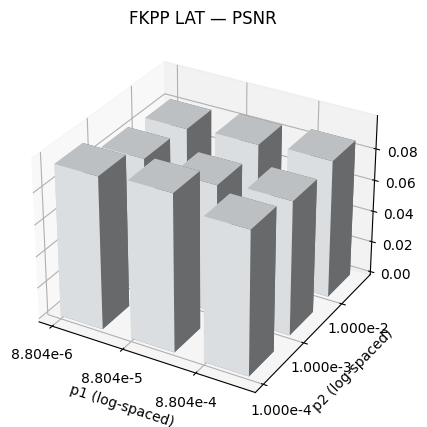

In [650]:
x = np.arange(len(p1_vals))   # [0,1,2]
y = np.arange(len(p2_vals))   # [0,1,2]

xx, yy = np.meshgrid(x, y)
xs = xx.ravel()
ys = yy.ravel()
zs = np.zeros_like(xs, dtype=float)

# bar heights
dz = []
for i in range(len(xs)):
    p1 = p1_vals[xs[i]]
    p2 = p2_vals[ys[i]]
    col = f"{reg}_{space}_{fmt_sci(p1)}_{p2}"
    dz.append(metric_pd[col].mean())

dz = np.array(dz)

norm = Normalize(vmin=30, vmax=34)
colors = cm.Blues(norm(dz))

# --- plot ---
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(xs, ys, zs, dx=0.6, dy=0.6, dz=dz, color=colors)

# --- axis ticks & labels ---
ax.set_xticks(x)
ax.set_xticklabels([fmt_sci(v) for v in p1_vals])
ax.set_yticks(y)
ax.set_yticklabels([fmt_sci(v) for v in p2_vals])

ax.set_xlabel("p1 (log-spaced)")
ax.set_ylabel("p2 (log-spaced)")
# ax.set_zlabel("RMSE")

ax.set_title(f"FKPP {space.upper()} — PSNR")

plt.tight_layout()
plt.show()

In [632]:
Z = np.full((len(p2_vals), len(p1_vals)), np.nan, dtype=float)

for i, p2 in enumerate(p2_vals):
    for j, p1 in enumerate(p1_vals):
        col = f"{reg}_{space}_{fmt_sci(p1)}_{p2}"
        Z[i, j] = metric_pd[col].mean() 
Z

array([[0.09599737, 0.09874049, 0.09034507],
       [0.08496937, 0.08126067, 0.08437839],
       [0.55736157, 0.08469256, 0.08685916]])

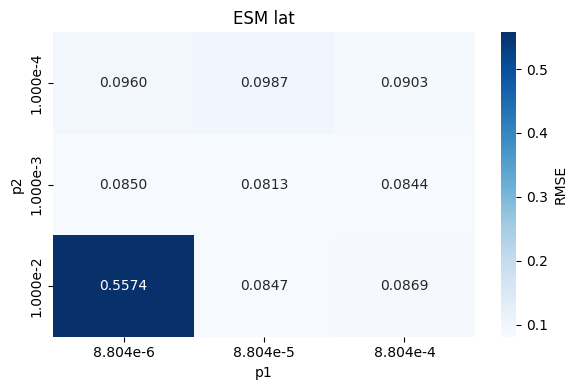

In [633]:
### heatmap

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    Z,
    annot=True,         
    fmt=".4f",
    cmap="Blues",
    vmin = metric_pd.mean().min(),
    vmax = metric_pd.mean().max(),
    xticklabels=[fmt_sci(v) for v in p1_vals],
    yticklabels=[fmt_sci(v) for v in p2_vals],
    cbar_kws={"label": "RMSE"},
    ax=ax
)

ax.set_xlabel("p1")
ax.set_ylabel("p2")
ax.set_title(f"{reg.upper()} {space.lower()}")

plt.tight_layout()
plt.show()


In [325]:
Z

array([[0.04489241, 0.05452747, 0.04426933],
       [0.04763571, 0.03973217, 0.04953882],
       [0.05041276, 0.04525787, 0.06121106]])

In [ ]:
### PLOTS TO COMPARE WITH NO REG

/Users/vibhabalaji/anaconda3/envs/GAN_Dec2022_DIGxgraph/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/vibhabalaji/anaconda3/envs/GAN_Dec2022_DIGxgraph/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/vibhabalaji/anaconda3/envs/GAN_Dec2022_DIGxgraph/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


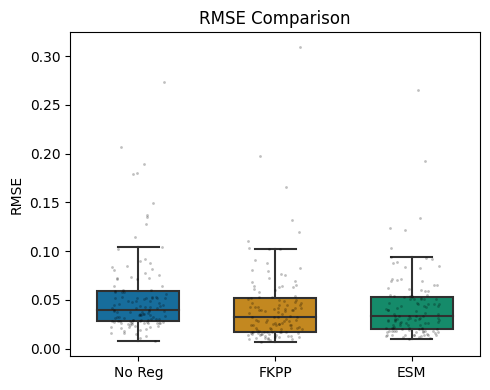

In [401]:
boxplot_pd = rmse_pd.copy()
metric = 'RMSE'

boxplot_pd = boxplot_pd.rename(columns={
    'no_reg': 'No Reg',
    'fkpp_lat_0.0645_0.0738': 'FKPP',
    'esm_lat_8.804e-5_0.001': 'ESM'
})
boxplot_pd = boxplot_pd.melt(var_name='Model', value_name=metric)

plt.figure(figsize=(5,4))

sns.boxplot(data=boxplot_pd, x='Model', y=metric, width=0.6, showfliers = False,
           palette=sns.color_palette("colorblind", 3))

sns.stripplot(data=boxplot_pd, x='Model', y=metric,
              color='black', alpha=0.25, size=2, jitter=0.2)
plt.ylabel(metric)
plt.xlabel("")
plt.title(f"{metric} Comparison")

plt.tight_layout()
# plt.show()
plt.savefig(f"../results revision/images/{metric}_boxplot.pdf")

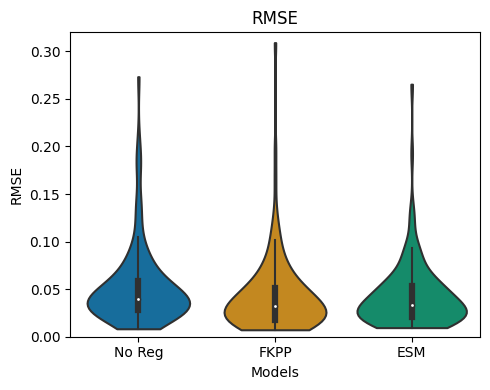

In [406]:
plt.figure(figsize=(5,4))

sns.violinplot(
    data=boxplot_pd,
    x='Model',
    y=metric,
    inner='box',
    cut=0,
    palette=sns.color_palette("colorblind", 3)
)

plt.ylim(0.0, 0.32)
plt.ylabel(metric)
plt.xlabel("Models")
plt.title(metric)
plt.tight_layout()
# plt.show()
plt.savefig(f"../results revision/images/{metric}_violinplot.pdf")

In [478]:
edge_index = torch.load('../data/66 ROIs processing HABS_ADNI/edge_index.pt')
habs_edge_weight = torch.load('../data/66 ROIs processing HABS_ADNI/habs_edge_weight.pt')
adni_edge_weight = torch.load('../data/66 ROIs processing HABS_ADNI/adni_edge_weight.pt')
edge_weight = torch.load('../data/66 ROIs processing HABS_ADNI/implemented_edge_weight.pt')

In [479]:
train_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_train_data_objects.pt')
val_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_val_data_objects.pt')
test_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_test_data_objects.pt')

In [480]:
A = torch.sparse_coo_tensor(edge_index, edge_weight[:,0], size = (66,66)).to_dense()
D = torch.diag(A.sum(dim=1))
L = D - A
L.to_sparse()
L = L.to(torch.float32)

In [481]:
from typing import List, Optional, Tuple, Union, Final

import torch.nn.functional as F
import torch
from torch import Tensor

from torch_geometric import EdgeIndex
from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor, OptTensor
from torch_geometric.utils import spmm


class GraphNetConv(MessagePassing):
    SUPPORTS_FUSED_EDGE_INDEX: Final[bool] = False
        
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
#         global_weight: bool = False,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
#         self.global_weight = global_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

#         if aggr == 'mlp':
#             kwargs.setdefault('aggr_kwargs', {})
#             kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
#             kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])
#             kwargs['aggr_kwargs'].setdefault('max_num_elements', in_channels[0]*2)
#             kwargs['aggr_kwargs'].setdefault('num_layers', 2)
#             kwargs['aggr_kwargs'].setdefault('hidden_channels', in_channels[0]*2)
            
        super().__init__(aggr=aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)
#         if self.global_weight:
#             self.lin_g = Linear(1, out_channels, bias = False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()
#         if self.global_weight:
#             self.lin_g.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        edge_weight: OptTensor = None,
#         u: OptTensor = None,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

#         propagate_type: (x: OptPairTensor, edge_weight: OptTensor)
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)
            
#         if self.global_weight:
#             out = out + self.lin_g(u)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor, edge_weight: OptTensor) -> Tensor:
        if edge_weight is not None:
#             edge_weight = edge_weight.view(-1,1)
#             print("inside message")
            x_j = edge_weight * x_j
            x_j = x_j.to(torch.float32)
        return x_j

#     def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
#         print("inside message and aggregate")
#         if isinstance(adj_t, SparseTensor):
            
#             adj_t = adj_t.set_value(None, layout=None)
#         return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

In [482]:
class GraphNet(nn.Module):
    def __init__(self):
        super(GraphNet, self).__init__()
        
        self.layer1 = GraphNetConv(1, 32, aggr='PowerMeanAggregation', flow="target_to_source")

        self.layer2 = GraphNetConv(32, 64, aggr='PowerMeanAggregation', flow="target_to_source")

        self.layer3 = GraphNetConv(64, 64, aggr='PowerMeanAggregation', flow="target_to_source")
        self.layer6 = GraphNetConv(64, 64, aggr='PowerMeanAggregation', flow="target_to_source")
        self.layer7 = GraphNetConv(64, 32, aggr='PowerMeanAggregation', flow="target_to_source")
#         self.layer8 = GraphNetConv(128, 64, aggr='PowerMeanAggregation', flow="target_to_source")
#         self.layer9 = GraphNetConv(64, 32, aggr='PowerMeanAggregation', flow="target_to_source")
        
        self.layer4 = GraphNetConv(32, 16, aggr='PowerMeanAggregation', flow="target_to_source")
        
        self.layer5 = GraphNetConv(16, 1, aggr='PowerMeanAggregation', flow="target_to_source")

        self.act = nn.LeakyReLU(negative_slope=0.01)
#         self.reset_parameters()  

#     def reset_parameters(self):
#         self.layer1.reset_parameters()
#         self.layer2.reset_parameters()
#         self.layer3.reset_parameters()
# #         self.layer6.reset_parameters()
# #         self.layer7.reset_parameters()
#         self.layer4.reset_parameters()
#         self.layer5.reset_parameters()

    def forward(self, x, edge_index, edge_weight):
        x = x.to(torch.float32)
        edge_weight = edge_weight.to(torch.float32)
        
        x = self.layer1(x, edge_index, edge_weight)                            
        x = self.act(x)

        x = self.layer2(x, edge_index, edge_weight)                            
        x = self.act(x)
        
        x = self.layer3(x, edge_index, edge_weight)                            
        x = self.act(x)
        x = self.layer6(x, edge_index, edge_weight)                            
        x = self.act(x)
        x = self.layer7(x, edge_index, edge_weight)                            
        x = self.act(x)
#         x = self.layer8(x, edge_index, edge_weight)                            
#         x = self.act(x)
#         x = self.layer9(x, edge_index, edge_weight)                            
#         x = self.act(x)
        
        x = self.layer4(x, edge_index, edge_weight)                            
        x = self.act(x)

        x = self.layer5(x, edge_index, edge_weight)
        return x

In [483]:
class GraphNet_ED(nn.Module):
    def __init__(self):
        super(GraphNet_ED, self).__init__()
        
        self.layer1 = GraphNetConv(1, 4, aggr='PowerMeanAggregation', flow="target_to_source")

#         self.layer2 = GraphNetConv(16, 16, aggr='PowerMeanAggregation', flow="target_to_source")

#         self.layer3 = GraphNetConv(32, 32, aggr='PowerMeanAggregation', flow="target_to_source")
#         self.layer6 = GraphNetConv(64, 64, aggr='PowerMeanAggregation', flow="target_to_source")
#         self.layer7 = GraphNetConv(64, 32, aggr='PowerMeanAggregation', flow="target_to_source")
        
#         self.layer4 = GraphNetConv(16, 16, aggr='PowerMeanAggregation', flow="target_to_source")
        
        self.layer5 = GraphNetConv(4, 1, aggr='PowerMeanAggregation', flow="target_to_source")

        self.act = nn.LeakyReLU(negative_slope=0.01)
        self.reset_parameters()  

    def reset_parameters(self):
        self.layer1.reset_parameters()
#         self.layer2.reset_parameters()
#         self.layer3.reset_parameters()
#         self.layer4.reset_parameters()
        self.layer5.reset_parameters()

    def forward(self, x, edge_index, edge_weight):
        x = x.to(torch.float32)
        edge_weight = edge_weight.to(torch.float32)
        
        x = self.layer1(x, edge_index, edge_weight)                            
        x = self.act(x)

#         x = self.layer2(x, edge_index, edge_weight)                            
#         x = self.act(x)
        
#         x = self.layer3(x, edge_index, edge_weight)                            
#         x = self.act(x)
#         x = self.layer6(x, edge_index, edge_weight)                            
#         x = self.act(x)
#         x = self.layer7(x, edge_index, edge_weight)                            
#         x = self.act(x)
        
#         x = self.layer4(x, edge_index, edge_weight)                            
#         x = self.act(x)

        x = self.layer5(x, edge_index, edge_weight)
        return x